# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-06-03 23:09:26.450878: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 23:09:26.553904: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-03 23:09:27.021787: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 23:09:27.021850: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 23:09:27.024828: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names

names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"]




data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=names)

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
## INSERT YOUR CODE HERE ##


data = data.drop(columns = ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'])

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
## INSERT YOUR CODE HERE ##
attack_labels = set(data['attack'])
attack_labels.discard('normal')
print(attack_labels)

data['attack'] = data['attack'].replace({label: 'attack' for label in attack_labels})

{'phf', 'portsweep', 'neptune', 'perl', 'multihop', 'back', 'loadmodule', 'satan', 'guess_passwd', 'warezclient', 'teardrop', 'warezmaster', 'smurf', 'ipsweep', 'buffer_overflow', 'spy', 'land', 'pod', 'ftp_write', 'rootkit', 'imap', 'nmap'}


In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
## INSERT YOUR CODE HERE ##

names = {'protocoltype', 'service', 'flag', 'attack'}

for col in names:
    le = LabelEncoder()
    labels = set(data[col])
    le.fit(list(labels))
    data[col] = le.transform(data[col])


In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

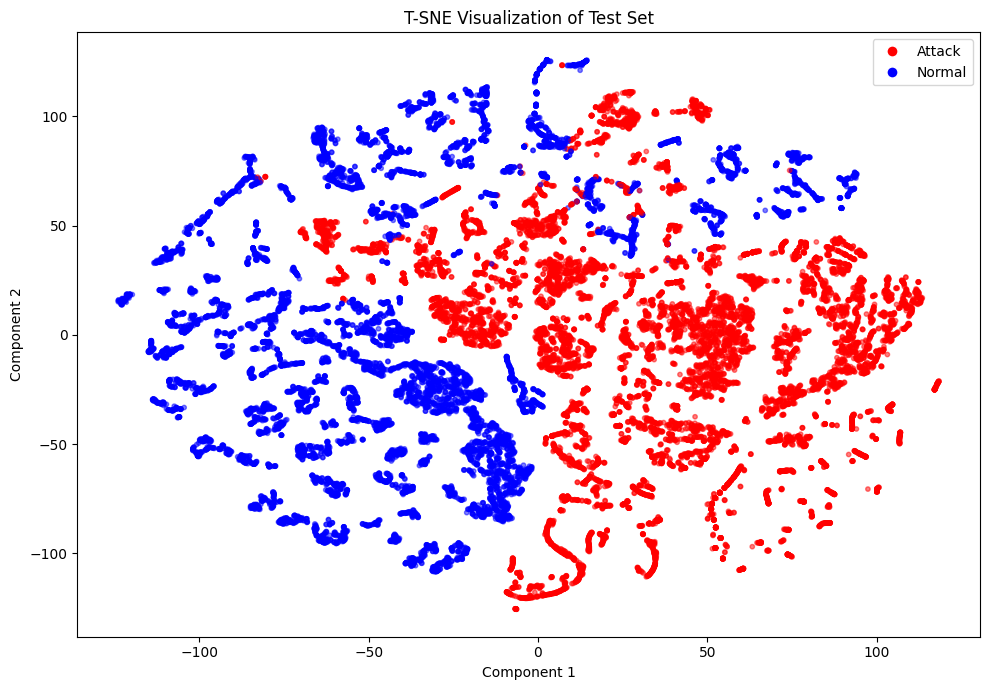

In [10]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##
guy = TSNE( n_components=2)

X_test_2d = guy.fit_transform(X_test)



colors = ['red' if label == 1 else 'blue' for label in y_test]
plt.figure(figsize=(10, 7))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors, alpha=0.5, s=10)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=8, label='Attack'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal')
]
plt.legend(handles=legend_elements)

plt.title('T-SNE Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()


##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

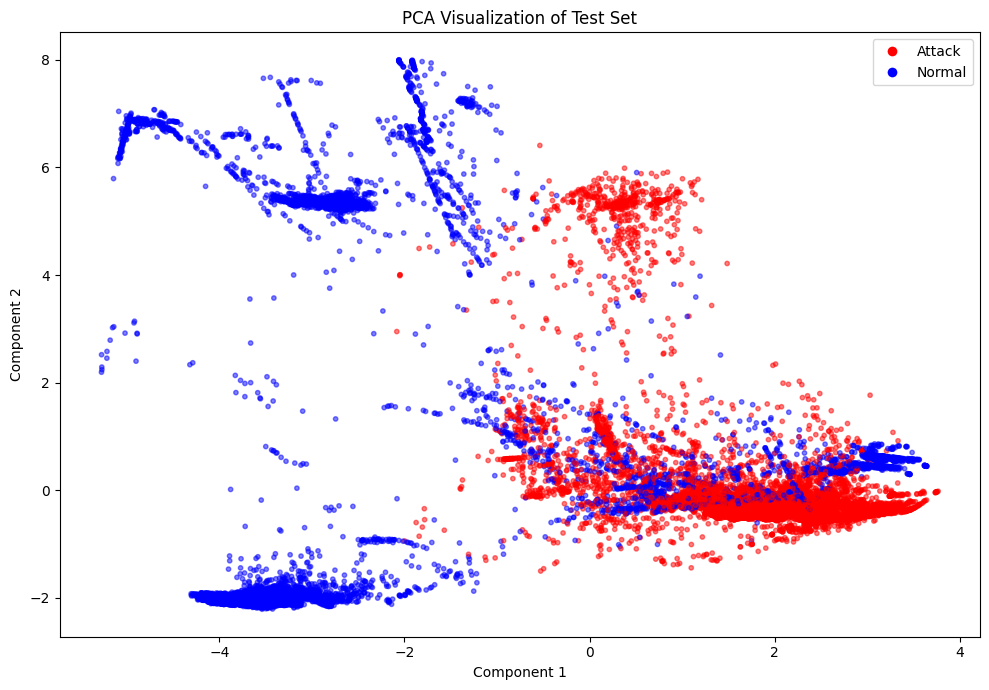

In [11]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##

PCA_guy = PCA(n_components=2)
XT_PCA = PCA_guy.fit_transform(X_test)



colors = ['red' if label == 1 else 'blue' for label in y_test]
plt.figure(figsize=(10, 7))
plt.scatter(XT_PCA[:, 0], XT_PCA[:, 1], c=colors, alpha=0.5, s=10)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=8, label='Attack'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal')
]
plt.legend(handles=legend_elements)

plt.title('PCA Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()


##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

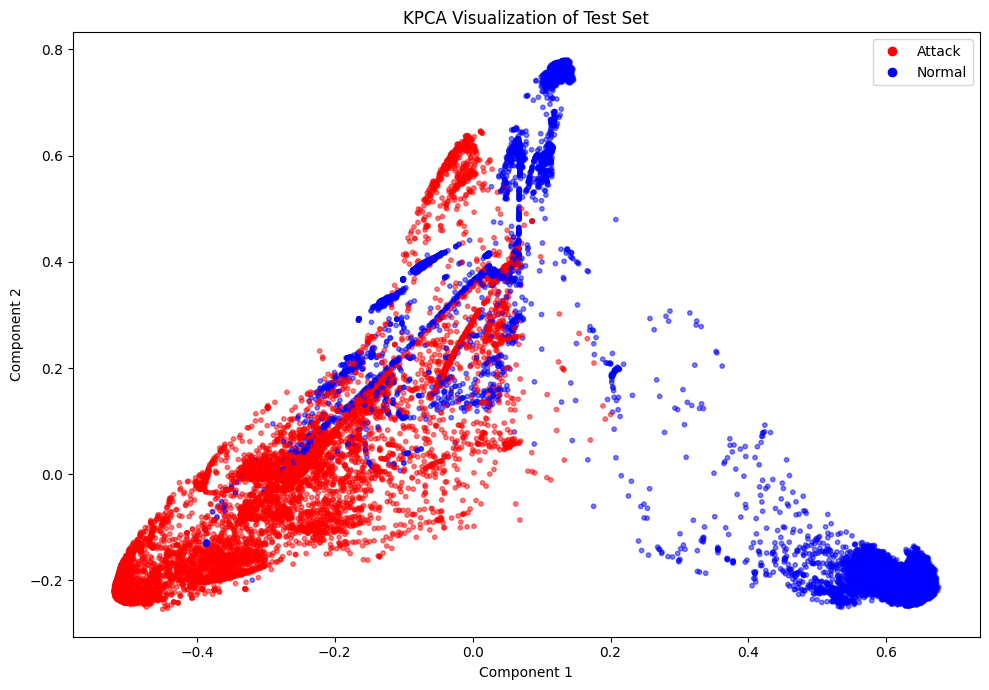

In [12]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##

##memory needed was tooo big
sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
KPCA_guy = KernelPCA(n_components=2, kernel='rbf')
KPCA_guy.fit(X_test[sample_idx])
##
XT_KPCA = KPCA_guy.transform(X_test)



colors = ['red' if label == 1 else 'blue' for label in y_test]
plt.figure(figsize=(10, 7))
plt.scatter(XT_KPCA[:, 0], XT_KPCA[:, 1], c=colors, alpha=0.5, s=10)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=8, label='Attack'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Normal')
]
plt.legend(handles=legend_elements)

plt.title('KPCA Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

In [14]:
# print("Unique classes in y_test:", np.unique(np.argmax(y_test, axis=1)))
# print("Class counts:", np.bincount(np.argmax(y_test, axis=1)))

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y  # ← this is critical
# )

# print("Unique classes in y_test:", np.unique(np.argmax(y_test, axis=1)))
# print("Class counts:", np.bincount(np.argmax(y_test, axis=1)))


In [15]:
# Define the DNN model
input_dim = X_train.shape[1]
print(input_dim)
model = Sequential([
    keras.Input(shape=(input_dim)),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])
model.summary()


38


2026-06-03 23:11:04.101190: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 23:11:04.254363: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                624       
                                                                 
 dense_1 (Dense)             (None, 2)                 34        
                                                                 
Total params: 658 (2.57 KB)
Trainable params: 658 (2.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [19]:
## INSERT YOUR CODE HERE ##

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    x=X_train,
    y=y_train,
    batch_size=64,
    epochs=10,
    callbacks=callbacks,
    validation_split=0.2,
)

base_model = model

Epoch 1/10
1260/1260 [==============================] - 6s 4ms/step - loss: 0.0074 - accuracy: 0.9971 - val_loss: 0.0070 - val_accuracy: 0.9974
Epoch 2/10
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0070 - accuracy: 0.9973 - val_loss: 0.0068 - val_accuracy: 0.9968
Epoch 3/10
1260/1260 [==============================] - 4s 4ms/step - loss: 0.0068 - accuracy: 0.9975 - val_loss: 0.0070 - val_accuracy: 0.9968
Epoch 4/10
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0064 - accuracy: 0.9974 - val_loss: 0.0067 - val_accuracy: 0.9969
Epoch 5/10
1260/1260 [==============================] - 3s 2ms/step - loss: 0.0063 - accuracy: 0.9975 - val_loss: 0.0063 - val_accuracy: 0.9974
Epoch 6/10
1260/1260 [==============================] - 4s 3ms/step - loss: 0.0062 - accuracy: 0.9975 - val_loss: 0.0071 - val_accuracy: 0.9969


##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 2s 2ms/step
Test Accuracy: 0.9972
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11740
      normal       1.00      1.00      1.00     13455

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



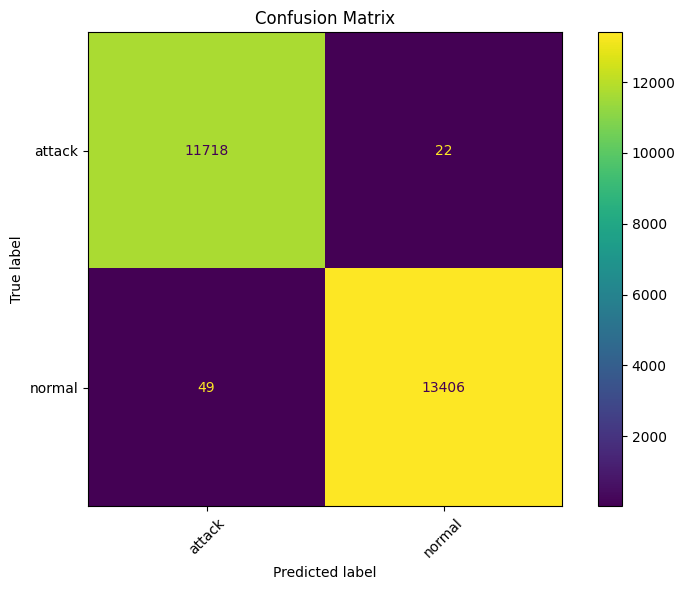

In [20]:
## INSERT YOUR CODE HERE ##
from sklearn.metrics import ConfusionMatrixDisplay

class_names = {"normal", "attack"}


# y_test is shape (n, 1) with raw class labels — don't use argmax
y_test_labels = y_test.squeeze()   # just flatten to (n,)
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)  # this is fine — y_prob IS 2D softmax output

test_accuracy = np.mean(y_pred == y_test_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")

print(classification_report(y_test_labels, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_labels, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [21]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [29]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpiarjeo_7/assets


INFO:tensorflow:Assets written to: /tmp/tmpiarjeo_7/assets
2026-06-03 23:35:43.060170: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-03 23:35:43.063954: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-03 23:35:43.083594: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpiarjeo_7
2026-06-03 23:35:43.091205: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-03 23:35:43.091792: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpiarjeo_7
2026-06-03 23:35:43.138896: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-03 23:35:43.140026: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-03 23:35:43.252952: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

In [30]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 32.74 KB
Quantized model size: 4.23 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     11740
      attack       1.00      1.00      1.00     13455

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



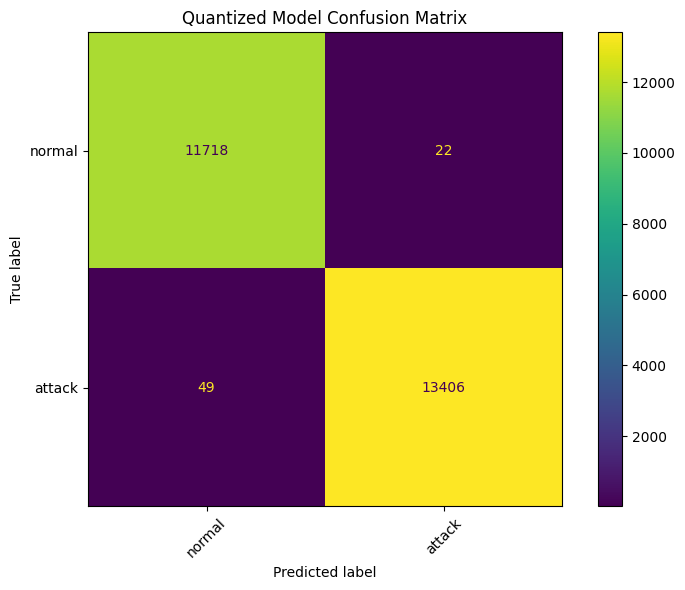

In [31]:
## INSERT YOUR CODE HERE ##

# Set up the TFLite interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run inference sample-by-sample (TFLite doesn't batch natively)
y_pred = []
for i in range(len(X_test)):
    sample = X_test[i].reshape(1, -1).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred.append(np.argmax(output))

y_pred = np.array(y_pred)

# Evaluate
y_test_labels = y_test.squeeze()

print(classification_report(y_test_labels, y_pred, target_names=['normal', 'attack']))

cm = confusion_matrix(y_test_labels, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=['normal', 'attack']).plot(ax=ax, xticks_rotation=45)
plt.title("Quantized Model Confusion Matrix")
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [32]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [33]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [34]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.00772306051278044, -0.004832850233580626, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6384484682501711, -0.23043658328669483, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.1102492232

In [35]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    1, 0, 0, 0, 0
};

